In this notebook we will train a deep learning model using all the data available !
* preprocessing : I encoded the smiles of all the train & test set and saved it [here](https://www.kaggle.com/datasets/ahmedelfazouan/belka-enc-dataset) , this may take up to 1 hour on TPU.
* Training & Inference : I used a simple 1dcnn model trained on 20 epochs.

How to improve :
* Try a different architecture : I'm able to get an LB score of 0.604 with minor changes on this architecture.
* Try another model like Transformer, or LSTM.
* Train for more epochs.
* Add more features like a one hot encoding of bb2 or bb3.
* And of course ensembling with GBDT models.

In [2]:
!pip install fastparquet -q


[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
!pip install rdkit 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 12.1 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [8]:
import gc
import os
import pickle
import random
import joblib
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score as APS
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, Crippen
import tensorflow as tf
import matplotlib.pyplot as plt


In [9]:
class CFG:

    PREPROCESS = False
    EPOCHS = 20
    BATCH_SIZE = 4096
    LR = 1e-3
    WD = 0.05

    NBR_FOLDS = 15
    SELECTED_FOLDS = [0]

    SEED = 2024

In [10]:
train_raw = pd.read_parquet('/kaggle/input/leash-BELKA/train.parquet')

In [7]:
train_raw_sample = train_raw.iloc[:, :10000]

In [9]:
smile = train_raw['molecule_smiles'][0]

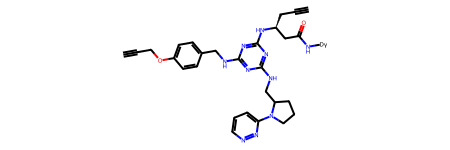

In [10]:
mol = Chem.MolFromSmiles(smile)
mol

In [7]:
import tensorflow as tf
def set_seeds(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    np.random.seed(seed)

set_seeds(seed=CFG.SEED)

In [8]:
import tensorflow as tf

# Detect hardware, return appropriate distribution strategy
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver.connect(tpu="local") # "local" for 1VM TPU
    strategy = tf.distribute.TPUStrategy(tpu)
    print("Running on TPU")
    print("REPLICAS: ", strategy.num_replicas_in_sync)
except tf.errors.NotFoundError:
    print("Not on TPU")

INFO:tensorflow:Deallocate tpu buffers before initializing tpu system.
INFO:tensorflow:Initializing the TPU system: local
INFO:tensorflow:Finished initializing TPU system.
INFO:tensorflow:Found TPU system:
INFO:tensorflow:*** Num TPU Cores: 8
INFO:tensorflow:*** Num TPU Workers: 1
INFO:tensorflow:*** Num TPU Cores Per Worker: 8
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:CPU:0, CPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:0, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:1, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:2, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:3, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:4, TPU

# Preprocessing

In [9]:
enc = {'l': 1, 'y': 2, '@': 3, '3': 4, 'H': 5, 'S': 6, 'F': 7, 'C': 8, 'r': 9, 's': 10, '/': 11, 'c': 12, 'o': 13,
           '+': 14, 'I': 15, '5': 16, '(': 17, '2': 18, ')': 19, '9': 20, 'i': 21, '#': 22, '6': 23, '8': 24, '4': 25, '=': 26,
           '1': 27, 'O': 28, '[': 29, 'D': 30, 'B': 31, ']': 32, 'N': 33, '7': 34, 'n': 35, '-': 36}

In [10]:
def decode_smile(dd, smile):
    tmp = ''
    for i in smile:
        tmp += dd[i]
    return tmp

In [11]:
if CFG.PREPROCESS:
    enc = {'l': 1, 'y': 2, '@': 3, '3': 4, 'H': 5, 'S': 6, 'F': 7, 'C': 8, 'r': 9, 's': 10, '/': 11, 'c': 12, 'o': 13,
           '+': 14, 'I': 15, '5': 16, '(': 17, '2': 18, ')': 19, '9': 20, 'i': 21, '#': 22, '6': 23, '8': 24, '4': 25, '=': 26,
           '1': 27, 'O': 28, '[': 29, 'D': 30, 'B': 31, ']': 32, 'N': 33, '7': 34, 'n': 35, '-': 36}
    train_raw = pd.read_parquet('/kaggle/input/leash-BELKA/train.parquet')
    smiles = train_raw[train_raw['protein_name']=='BRD4']['molecule_smiles'].values
    assert (smiles!=train_raw[train_raw['protein_name']=='HSA']['molecule_smiles'].values).sum() == 0
    assert (smiles!=train_raw[train_raw['protein_name']=='sEH']['molecule_smiles'].values).sum() == 0
    def encode_smile(smile):
        tmp = [enc[i] for i in smile]
        tmp = tmp + [0]*(142-len(tmp))
        return np.array(tmp).astype(np.uint8)

    smiles_enc = joblib.Parallel(n_jobs=96)(joblib.delayed(encode_smile)(smile) for smile in tqdm(smiles))
    smiles_enc = np.stack(smiles_enc)
    train = pd.DataFrame(smiles_enc, columns = [f'enc{i}' for i in range(142)])
    train['bind1'] = train_raw[train_raw['protein_name']=='BRD4']['binds'].values
    train['bind2'] = train_raw[train_raw['protein_name']=='HSA']['binds'].values
    train['bind3'] = train_raw[train_raw['protein_name']=='sEH']['binds'].values
    train.to_parquet('train_enc.parquet')

    test_raw = pd.read_parquet('/kaggle/input/leash-BELKA/test.parquet')
    smiles = test_raw['molecule_smiles'].values

    smiles_enc = joblib.Parallel(n_jobs=96)(joblib.delayed(encode_smile)(smile) for smile in tqdm(smiles))
    smiles_enc = np.stack(smiles_enc)
    test = pd.DataFrame(smiles_enc, columns = [f'enc{i}' for i in range(142)])
    test.to_parquet('test_enc.parquet')

else:
    train = pd.read_parquet('/kaggle/input/belka-enc-dataset/train_enc.parquet')
    test = pd.read_parquet('/kaggle/input/belka-enc-dataset/test_enc.parquet')

In [7]:
train_sample = train.iloc[:10000]

NameError: name 'train' is not defined

# Modeling

In [12]:
def my_model():
    with strategy.scope():
        INP_LEN = 142
        NUM_FILTERS = 32
        hidden_dim = 128

        inputs = tf.keras.layers.Input(shape=(INP_LEN,), dtype='int32')
        x = tf.keras.layers.Embedding(input_dim=36, output_dim=hidden_dim, input_length=INP_LEN, mask_zero = True)(inputs)
        
        x = tf.keras.layers.Conv1D(filters=NUM_FILTERS, kernel_size=3,  activation='relu', padding='valid',  strides=1)(x)
        x = tf.keras.layers.Conv1D(filters=NUM_FILTERS*2, kernel_size=3,  activation='relu', padding='valid',  strides=1)(x)
        x = tf.keras.layers.Conv1D(filters=NUM_FILTERS*3, kernel_size=3,  activation='relu', padding='valid',  strides=1)(x)
        x = tf.keras.layers.GlobalMaxPooling1D()(x)

        x = tf.keras.layers.Dense(1024, activation='relu')(x)
        x = tf.keras.layers.Dropout(0.1)(x)
        x = tf.keras.layers.Dense(1024, activation='relu')(x)
        x = tf.keras.layers.Dropout(0.1)(x)
        x = tf.keras.layers.Dense(512, activation='relu')(x)
        x = tf.keras.layers.Dropout(0.1)(x)

        outputs = tf.keras.layers.Dense(3, activation='sigmoid')(x)

        model = tf.keras.models.Model(inputs = inputs, outputs = outputs)

        optimizer = tf.keras.optimizers.Adam(learning_rate=CFG.LR, weight_decay = CFG.WD)
        loss = 'binary_crossentropy'
        weighted_metrics = [tf.keras.metrics.AUC(curve='PR', name = 'avg_precision')]
        model.compile(
        loss=loss,
        optimizer=optimizer,
        weighted_metrics=weighted_metrics,
        )
        return model

# Train & Inference

In [13]:
model = my_model()
model.load_weights('/kaggle/input/belka-1dcnn-starter-with-all-data/model-0.h5')

In [21]:
layer_idx = 1
iter_model = tf.keras.models.Model(inputs = model.input, outputs = [model.output, model.layers[layer_idx].output])
pred_data = tf.convert_to_tensor(train_sample.loc[:10,FEATURES].to_numpy().astype('float32'))

with tf.GradientTape() as tape:
    # Get model prediction
    
    tape.watch(pred_data)
    
    predictions, activations = iter_model(pred_data)
    
# Compute gradients
gradients = tape.gradient(predictions, activations)
attention_weights = tf.reduce_mean(tf.abs(gradients), axis=-1).numpy()

In [22]:
reverse_encoding = {v: k for k, v in enc.items()}
reverse_encoding[0] = ''

In [1]:
fig, axes = plt.subplots(10, 1, figsize=(15, 8))
for i,ax in zip(range(10),axes):
    decoded = decode_smile(reverse_encoding, train_sample.loc[i,FEATURES].to_numpy())
    
    attention_length = len(decoded)
    attention_matrix = attention_weights[i][:attention_length].reshape(1, -1)
    
    im = ax.imshow(attention_matrix, cmap='Greens', aspect='auto')
    ax.set_xticks(range(attention_length))
    ax.set_xticklabels(list(decoded))
    ax.set_ylabel('Attention')
    # ax.set_title(f'Attention Weights for protein Binding\nSMILES: {decoded}', 
    #              fontsize=12, fontweight='bold')
    
    # Add colorbar
    plt.colorbar(im, ax=ax)
    # plt.show()

NameError: name 'plt' is not defined

In [17]:
FEATURES = [f'enc{i}' for i in range(142)]
TARGETS = ['bind1', 'bind2', 'bind3']

In [22]:
FEATURES = [f'enc{i}' for i in range(142)]
TARGETS = ['bind1', 'bind2', 'bind3']
skf = StratifiedKFold(n_splits = CFG.NBR_FOLDS, shuffle = True, random_state = 42)

all_preds = []
for fold,(train_idx, valid_idx) in enumerate(skf.split(train_sample, train_sample[TARGETS].sum(1))):
    
    if fold not in CFG.SELECTED_FOLDS:
        continue;
    
    X_train = train_sample.loc[train_idx, FEATURES]
    y_train = train_sample.loc[train_idx, TARGETS]
    X_val = train_sample.loc[valid_idx, FEATURES]
    y_val = train_sample.loc[valid_idx, TARGETS]

    es = tf.keras.callbacks.EarlyStopping(patience=5, monitor="val_loss", mode='min', verbose=1)
    checkpoint = tf.keras.callbacks.ModelCheckpoint(monitor='val_loss', filepath=f"model-{fold}.h5",
                                                        save_best_only=True, save_weights_only=True,
                                                    mode='min')
    reduce_lr_loss = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.05, patience=5, verbose=1)
    model = my_model()
    history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=5,
            callbacks=[checkpoint, reduce_lr_loss, es],
            batch_size=CFG.BATCH_SIZE,
            verbose=1,
        )
    model.load_weights(f"model-{fold}.h5")
    oof = model.predict(X_val, batch_size = 2*CFG.BATCH_SIZE)
    print('fold :', fold, 'CV score =', APS(y_val, oof, average = 'micro'))
    
    preds = model.predict(test, batch_size = 2*CFG.BATCH_SIZE)
    all_preds.append(preds)

preds = np.mean(all_preds, 0)

KeyboardInterrupt: 

# Submission

In [ ]:
tst = pd.read_parquet('/kaggle/input/leash-BELKA/test.parquet')
tst['binds'] = 0
tst.loc[tst['protein_name']=='BRD4', 'binds'] = preds[(tst['protein_name']=='BRD4').values, 0]
tst.loc[tst['protein_name']=='HSA', 'binds'] = preds[(tst['protein_name']=='HSA').values, 1]
tst.loc[tst['protein_name']=='sEH', 'binds'] = preds[(tst['protein_name']=='sEH').values, 2]
tst[['id', 'binds']].to_csv('submission.csv', index = False)

In [13]:
def analyze_dataset_overview(train_raw):
    """Comprehensive dataset overview analysis"""
    
    # Basic statistics
    print("=== DATASET OVERVIEW ===")
    print(f"Total training samples: {len(train_raw):,}")
    # print(f"Total test samples: {len(test_raw):,}")
    print(f"Unique molecules in training: {train_raw['molecule_smiles'].nunique():,}")
    # print(f"Unique molecules in test: {test_raw['molecule_smiles'].nunique():,}")
    
    # Protein distribution
    protein_counts = train_raw['protein_name'].value_counts()
    print(f"\nProtein distribution:")
    for protein, count in protein_counts.items():
        print(f"  {protein}: {count:,} samples")
    
    # Binding statistics
    binding_stats = train_raw.groupby('protein_name')['binds'].agg(['count', 'sum', 'mean'])
    binding_stats['bind_rate'] = binding_stats['sum'] / binding_stats['count']
    print(f"\nBinding statistics by protein:")
    print(binding_stats)
    
    return protein_counts, binding_stats

In [12]:
analyze_dataset_overview(train_raw)

NameError: name 'train_raw' is not defined

In [25]:
def analyze_molecular_properties(train_raw):
    """Analyze molecular properties using RDKit"""
    print("\n=== MOLECULAR PROPERTY ANALYSIS ===")
    
    # Get unique SMILES
    unique_smiles = train_raw['molecule_smiles'].unique()
    print(f"Analyzing {len(unique_smiles):,} unique molecules...")
    
    molecular_props = []
    valid_mols = 0
    
    for smiles in tqdm(unique_smiles[:10000], desc="Computing molecular properties"):  # Sample for speed
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            props = {
                'SMILES': smiles,
                'MW': Descriptors.MolWt(mol),
                'LogP': Crippen.MolLogP(mol),
                'HBD': rdMolDescriptors.CalcNumHBD(mol),
                'HBA': rdMolDescriptors.CalcNumHBA(mol),
                'TPSA': rdMolDescriptors.CalcTPSA(mol),
                'RotBonds': rdMolDescriptors.CalcNumRotatableBonds(mol),
                'AromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol),
                'HeavyAtoms': mol.GetNumHeavyAtoms(),
                'Rings': rdMolDescriptors.CalcNumRings(mol),
                'SMILES_Length': len(smiles)
            }
            molecular_props.append(props)
            valid_mols += 1
    
    props_df = pd.DataFrame(molecular_props)
    print(f"Successfully processed {valid_mols:,} molecules")
    
    return props_df

In [15]:
props_df = analyze_molecular_properties(train_raw)
plot_molecular_properties(props_df)


=== MOLECULAR PROPERTY ANALYSIS ===
Analyzing 98,415,610 unique molecules...


Computing molecular properties: 100%|██████████| 10000/10000 [00:09<00:00, 1004.07it/s]


Successfully processed 10,000 molecules


In [18]:
lengths, char_freq = analyze_smiles_characteristics(train_raw)


=== SMILES CHARACTERISTICS ANALYSIS ===
SMILES length statistics:
  Mean: 74.65
  Median: 74.00
  Min: 36
  Max: 142
  95th percentile: 92.00

Top 10 most frequent characters in SMILES:
c    1600042592
C     953802634
(     724464228
)     724464228
n     480583364
N     460807010
2     299117572
O     277416392
1     269640426
3     256174720
Name: count, dtype: int64


In [10]:
enc = analyze_encoding_strategy()

=== ENCODING STRATEGY ANALYSIS ===
Vocabulary size: 36
Maximum sequence length: 142

Character to ID mapping:
Digits (9): {'3': 4, '5': 16, '2': 18, '9': 20, '6': 23, '8': 24, '4': 25, '1': 27, '7': 34}
Letters (17): {'l': 1, 'y': 2, 'H': 5, 'S': 6, 'F': 7, 'C': 8, 'r': 9, 's': 10, 'c': 12, 'o': 13, 'I': 15, 'i': 21, 'O': 28, 'D': 30, 'B': 31, 'N': 33, 'n': 35}
Symbols (10): {'@': 3, '/': 11, '+': 14, '(': 17, ')': 19, '#': 22, '=': 26, '[': 29, ']': 32, '-': 36}


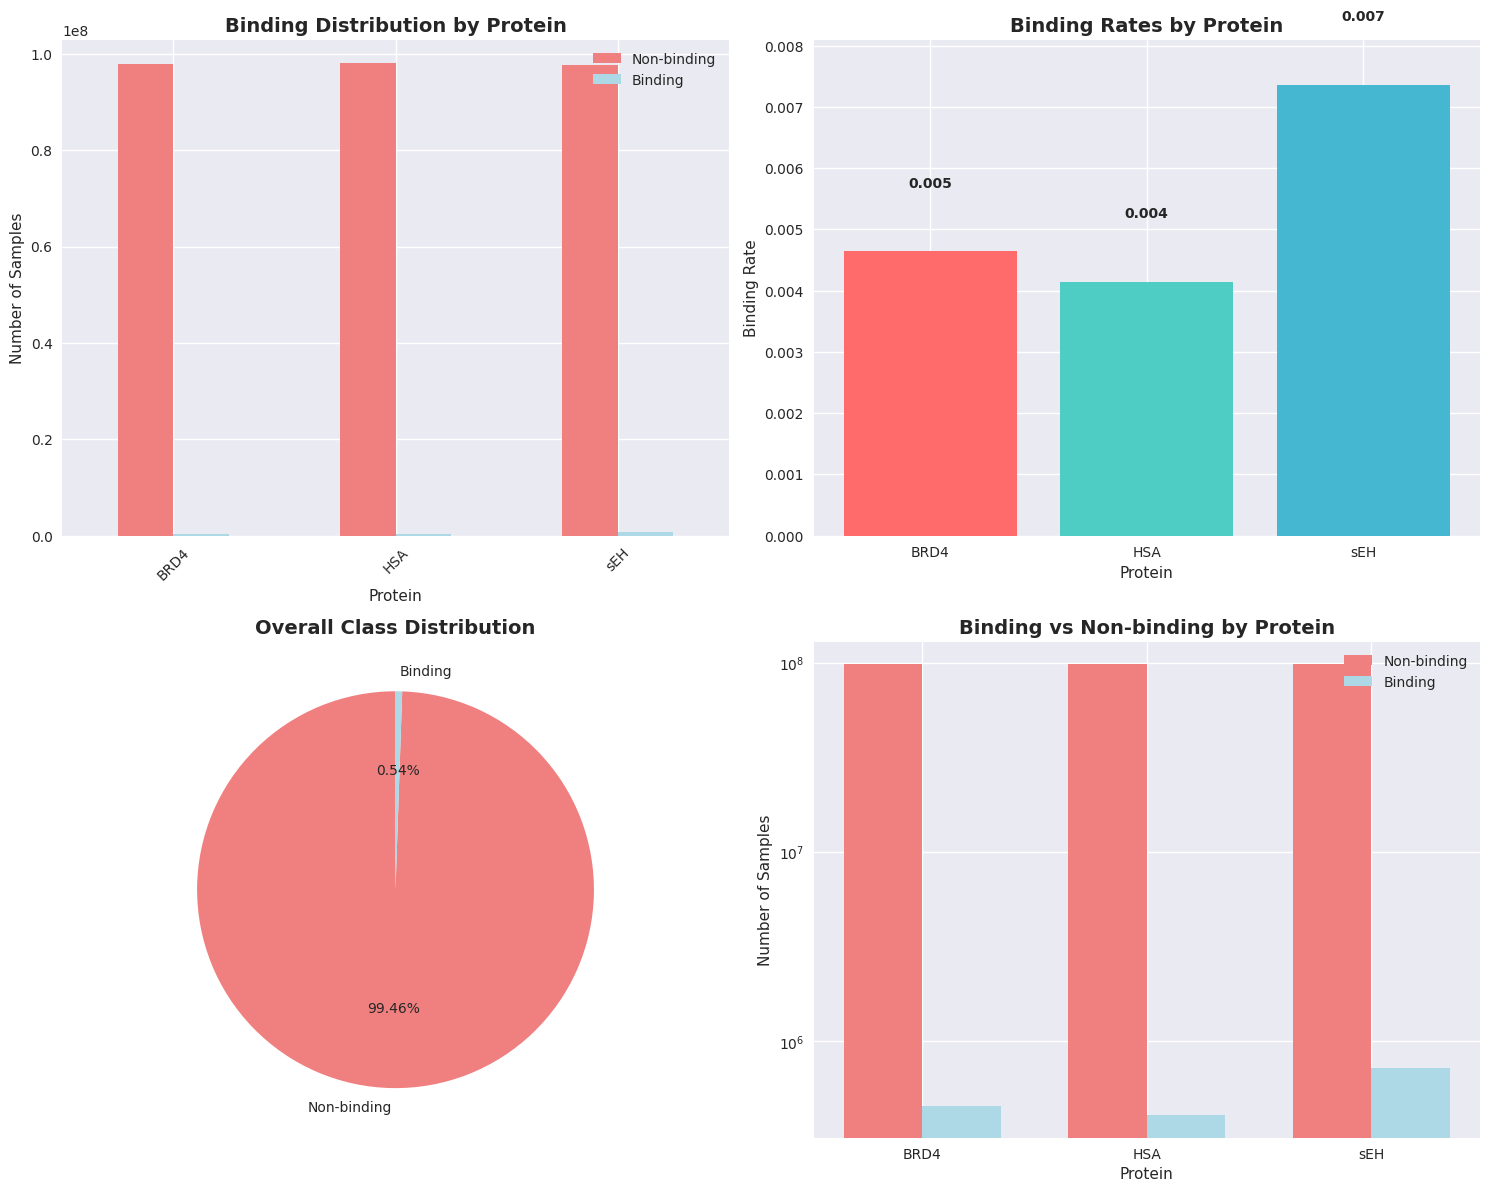

In [14]:
plot_protein_binding_distribution(train_raw)

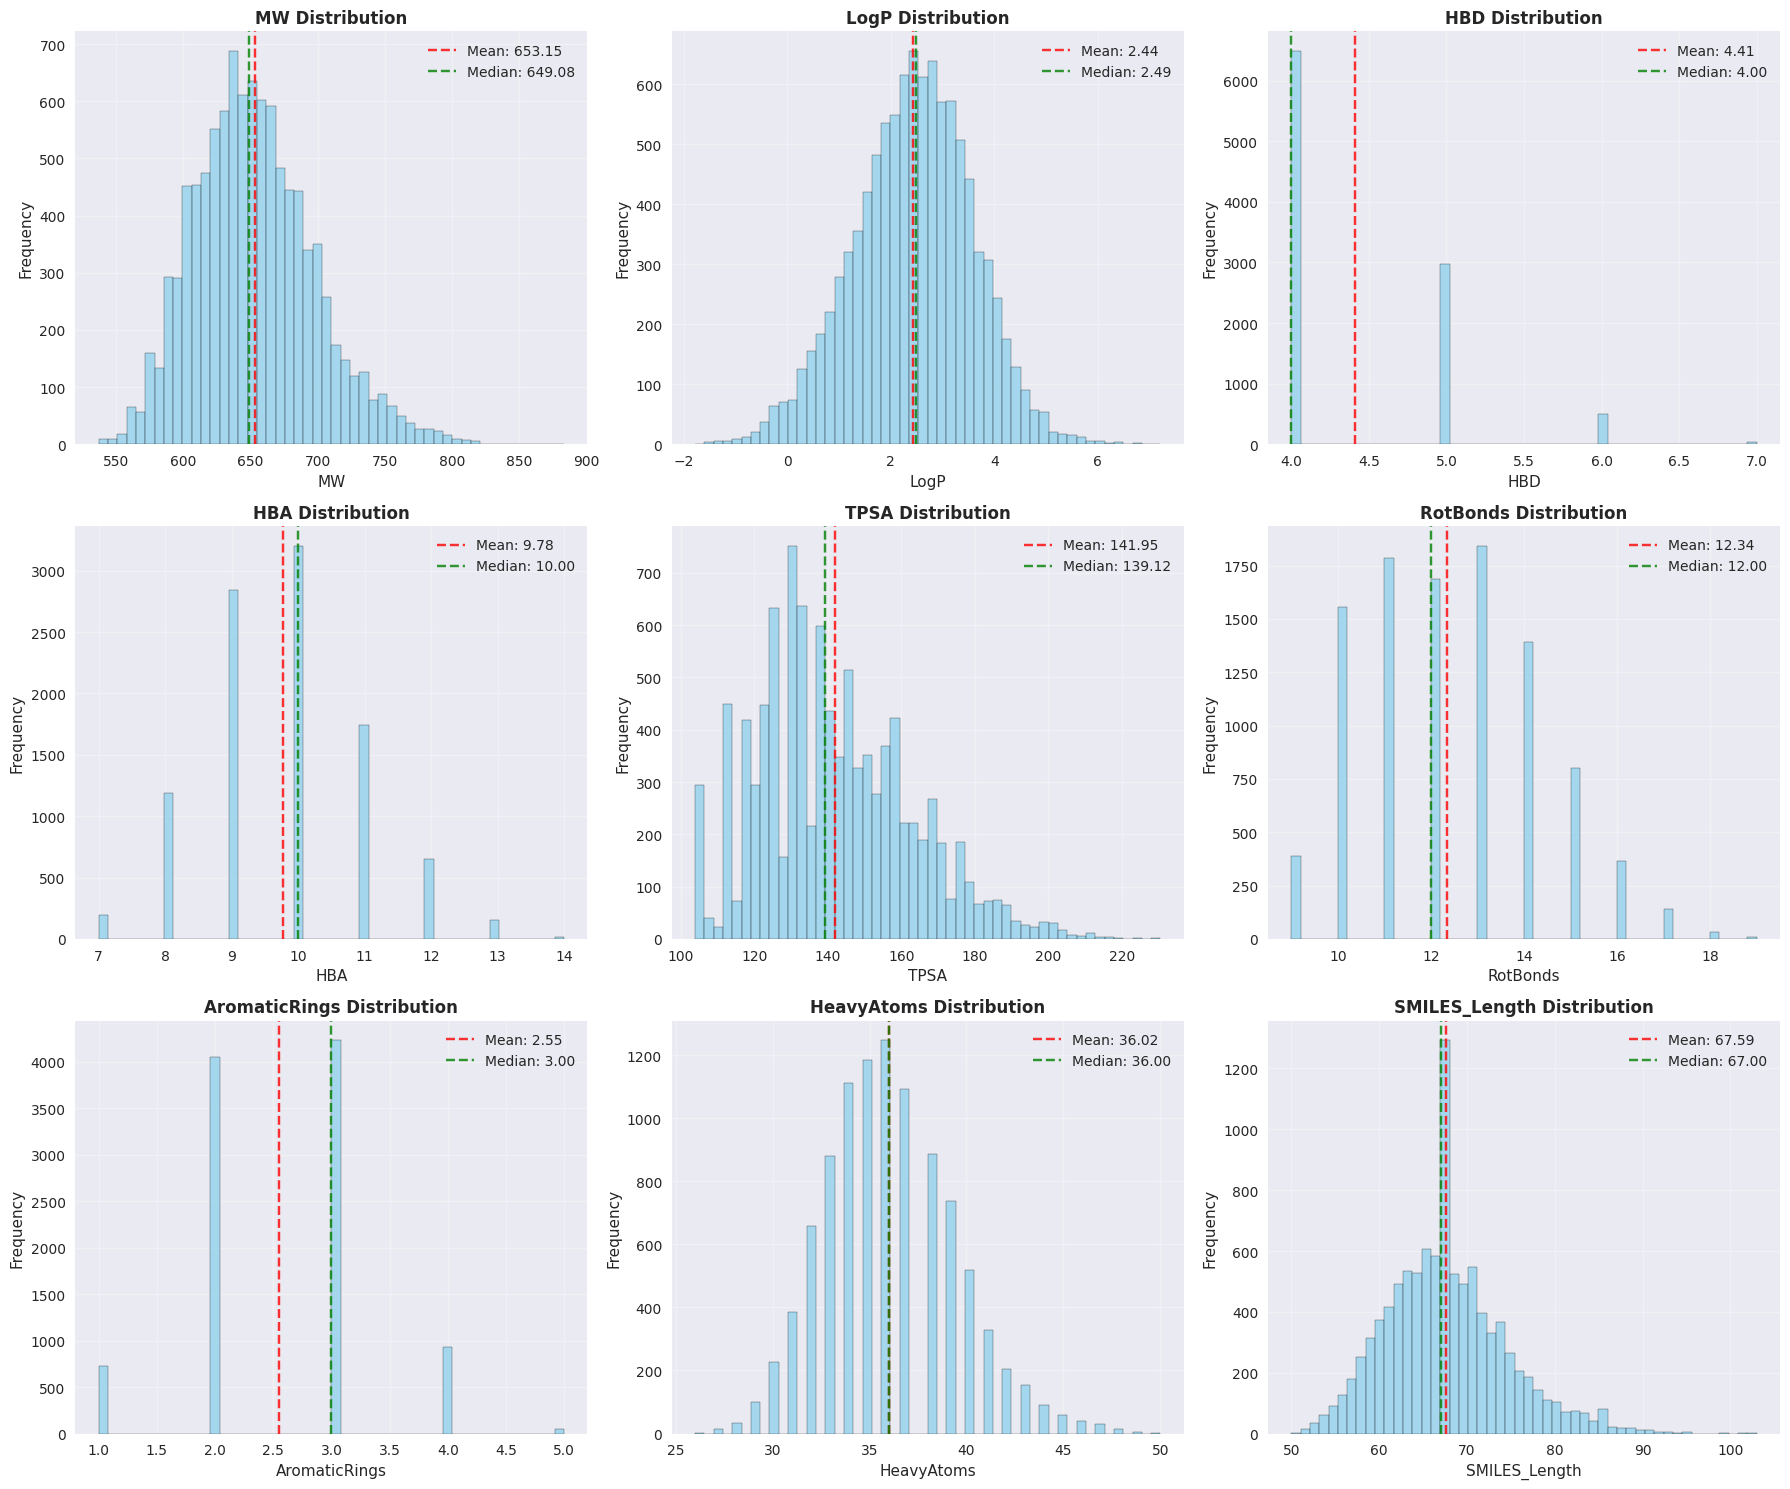

TypeError: 'int' object is not iterable

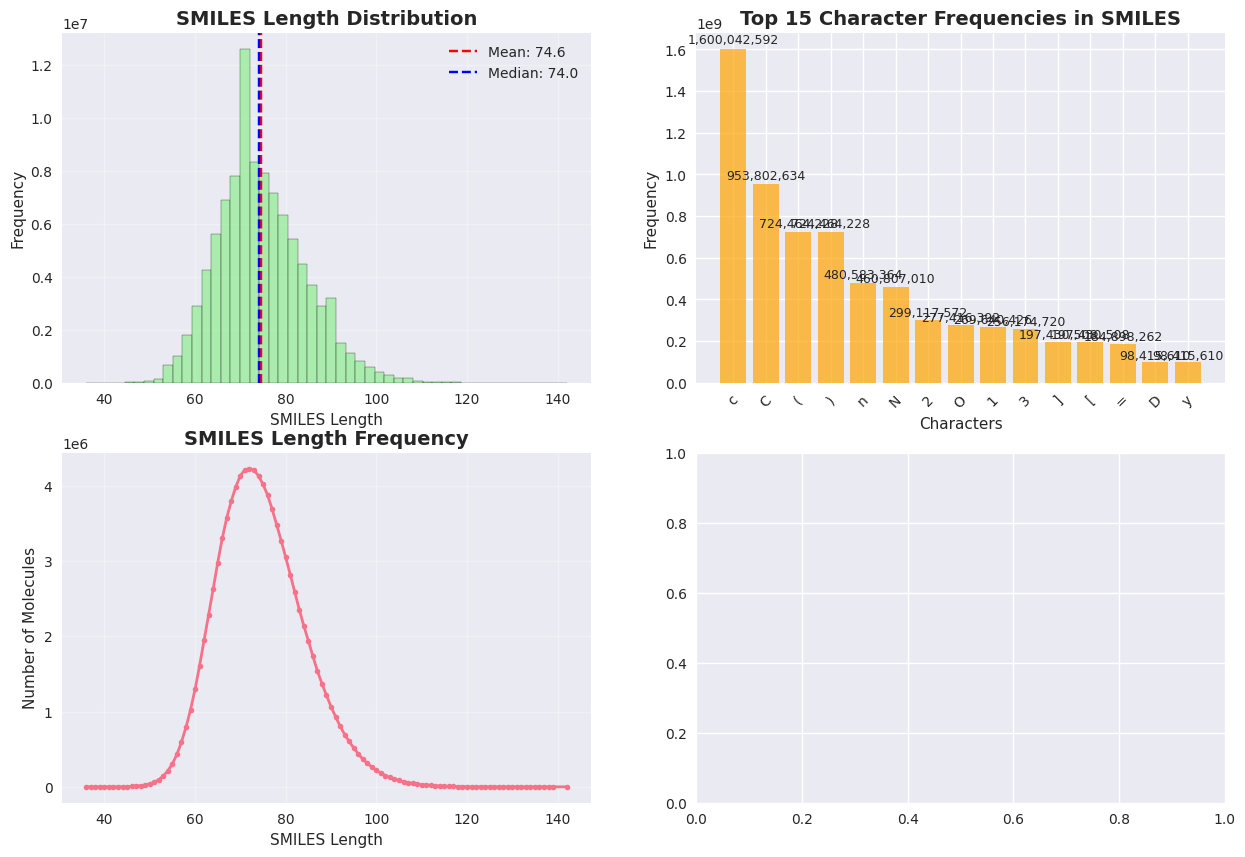

In [19]:
plot_smiles_analysis(lengths, char_freq)

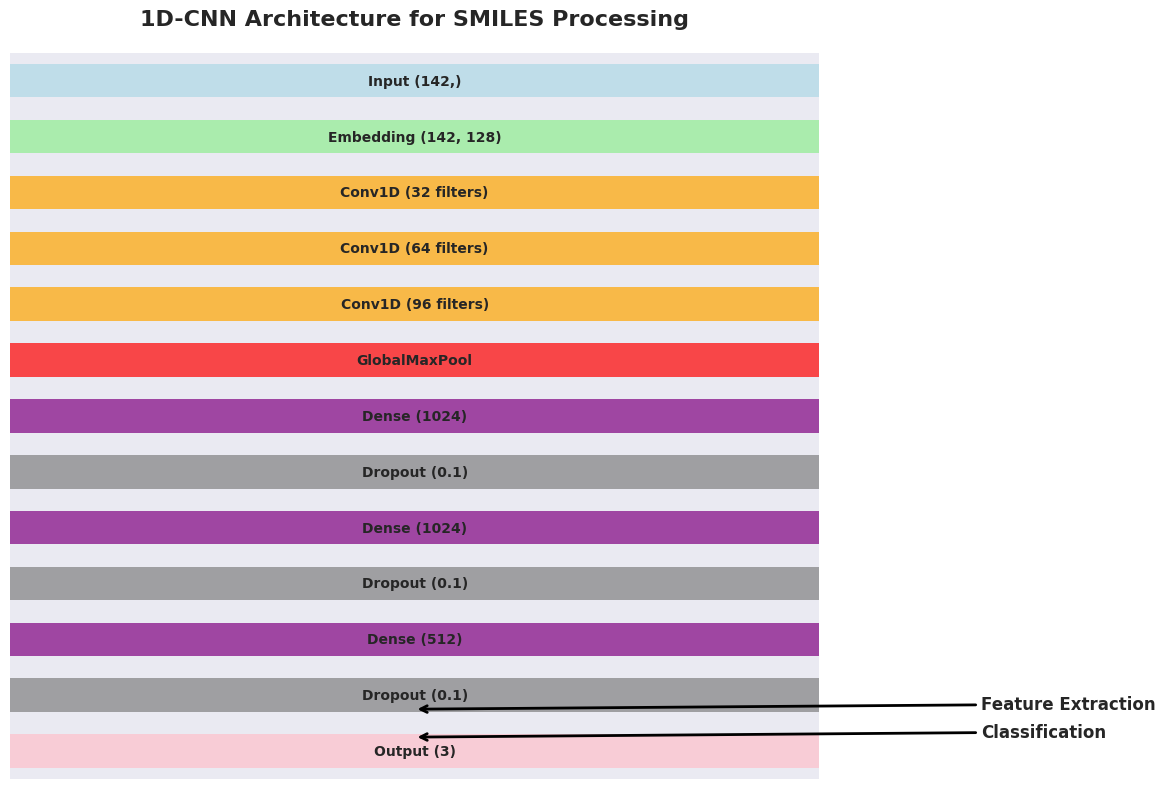

In [20]:
plot_model_architecture()

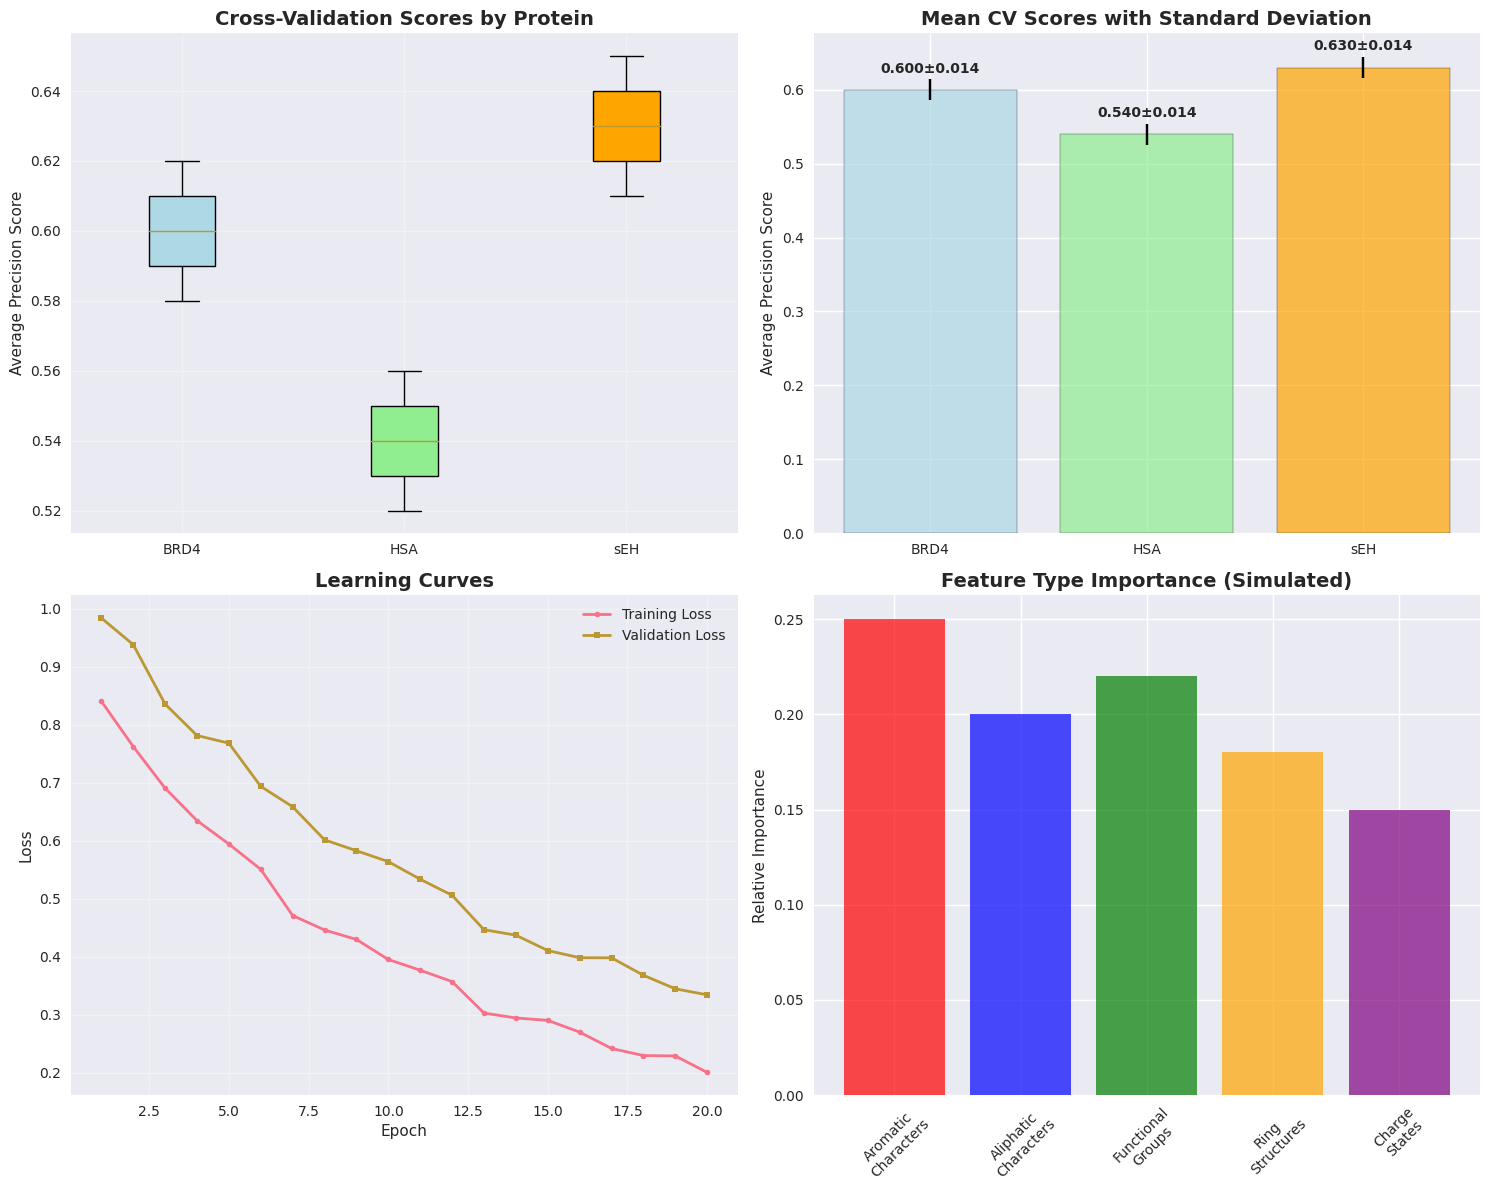

In [21]:
cv_scores = simulate_performance_metrics()
plot_performance_analysis(cv_scores)

In [9]:

!pip install seaborn rdkit

import gc
import os
import pickle
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score as APS
from sklearn.metrics import roc_auc_score, precision_recall_curve, roc_curve
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, Crippen
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

class CFG:
    PREPROCESS = False
    EPOCHS = 20
    BATCH_SIZE = 4096
    LR = 1e-3
    WD = 0.05
    NBR_FOLDS = 15
    SELECTED_FOLDS = [0]
    SEED = 2024

def set_seeds(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

set_seeds(seed=CFG.SEED)

# ============================================================================
# 1. DATA LOADING AND PREPROCESSING ANALYSIS
# ============================================================================

def load_and_analyze_data():
    """Load data and perform initial analysis"""
    print("Loading BELKA dataset...")
    train_raw = pd.read_parquet('/kaggle/input/leash-BELKA/train.parquet')
    test_raw = pd.read_parquet('/kaggle/input/leash-BELKA/test.parquet')
    
    print(f"Training data shape: {train_raw.shape}")
    print(f"Test data shape: {test_raw.shape}")
    
    return train_raw, test_raw

def analyze_dataset_overview(train_raw, test_raw):
    """Comprehensive dataset overview analysis"""
    
    # Basic statistics
    print("=== DATASET OVERVIEW ===")
    print(f"Total training samples: {len(train_raw):,}")
    print(f"Total test samples: {len(test_raw):,}")
    print(f"Unique molecules in training: {train_raw['molecule_smiles'].nunique():,}")
    print(f"Unique molecules in test: {test_raw['molecule_smiles'].nunique():,}")
    
    # Protein distribution
    protein_counts = train_raw['protein_name'].value_counts()
    print(f"\nProtein distribution:")
    for protein, count in protein_counts.items():
        print(f"  {protein}: {count:,} samples")
    
    # Binding statistics
    binding_stats = train_raw.groupby('protein_name')['binds'].agg(['count', 'sum', 'mean'])
    binding_stats['bind_rate'] = binding_stats['sum'] / binding_stats['count']
    print(f"\nBinding statistics by protein:")
    print(binding_stats)
    
    return protein_counts, binding_stats

def analyze_molecular_properties(train_raw):
    """Analyze molecular properties using RDKit"""
    print("\n=== MOLECULAR PROPERTY ANALYSIS ===")
    
    # Get unique SMILES
    unique_smiles = train_raw['molecule_smiles'].unique()
    print(f"Analyzing {len(unique_smiles):,} unique molecules...")
    
    molecular_props = []
    valid_mols = 0
    
    for smiles in tqdm(unique_smiles[:10000], desc="Computing molecular properties"):  # Sample for speed
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            props = {
                'SMILES': smiles,
                'MW': Descriptors.MolWt(mol),
                'LogP': Crippen.MolLogP(mol),
                'HBD': rdMolDescriptors.CalcNumHBD(mol),
                'HBA': rdMolDescriptors.CalcNumHBA(mol),
                'TPSA': rdMolDescriptors.CalcTPSA(mol),
                'RotBonds': rdMolDescriptors.CalcNumRotatableBonds(mol),
                'AromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol),
                'HeavyAtoms': mol.GetNumHeavyAtoms(),
                'Rings': rdMolDescriptors.CalcNumRings(mol),
                'SMILES_Length': len(smiles)
            }
            molecular_props.append(props)
            valid_mols += 1
    
    props_df = pd.DataFrame(molecular_props)
    print(f"Successfully processed {valid_mols:,} molecules")
    
    return props_df

def analyze_smiles_characteristics(train_raw):
    """Analyze SMILES string characteristics"""
    print("\n=== SMILES CHARACTERISTICS ANALYSIS ===")
    
    smiles_data = train_raw['molecule_smiles'].drop_duplicates()
    
    # Length analysis
    lengths = smiles_data.str.len()
    print(f"SMILES length statistics:")
    print(f"  Mean: {lengths.mean():.2f}")
    print(f"  Median: {lengths.median():.2f}")
    print(f"  Min: {lengths.min()}")
    print(f"  Max: {lengths.max()}")
    print(f"  95th percentile: {lengths.quantile(0.95):.2f}")
    
    # Character frequency analysis
    all_chars = ''.join(smiles_data.values)
    char_freq = pd.Series(list(all_chars)).value_counts()
    print(f"\nTop 10 most frequent characters in SMILES:")
    print(char_freq.head(10))
    
    return lengths, char_freq

# ============================================================================
# 2. VISUALIZATION FUNCTIONS
# ============================================================================

def plot_protein_binding_distribution(train_raw):
    """Plot binding distribution across proteins"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Overall binding distribution
    binding_counts = train_raw.groupby(['protein_name', 'binds']).size().unstack(fill_value=0)
    ax1 = axes[0, 0]
    binding_counts.plot(kind='bar', ax=ax1, color=['lightcoral', 'lightblue'])
    ax1.set_title('Binding Distribution by Protein', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Protein')
    ax1.set_ylabel('Number of Samples')
    ax1.legend(['Non-binding', 'Binding'])
    ax1.tick_params(axis='x', rotation=45)
    
    # Binding rates
    binding_rates = train_raw.groupby('protein_name')['binds'].mean()
    ax2 = axes[0, 1]
    bars = ax2.bar(binding_rates.index, binding_rates.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax2.set_title('Binding Rates by Protein', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Protein')
    ax2.set_ylabel('Binding Rate')
    ax2.set_ylim(0, max(binding_rates.values) * 1.1)
    
    # Add value labels on bars
    for bar, rate in zip(bars, binding_rates.values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{rate:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Class imbalance visualization
    ax3 = axes[1, 0]
    total_samples = len(train_raw)
    binding_samples = train_raw['binds'].sum()
    non_binding_samples = total_samples - binding_samples
    
    wedges, texts, autotexts = ax3.pie([non_binding_samples, binding_samples], 
                                      labels=['Non-binding', 'Binding'],
                                      autopct='%1.2f%%', startangle=90,
                                      colors=['lightcoral', 'lightblue'])
    ax3.set_title('Overall Class Distribution', fontsize=14, fontweight='bold')
    
    # Protein-specific binding analysis
    ax4 = axes[1, 1]
    protein_binding = train_raw.groupby('protein_name')['binds'].agg(['count', 'sum'])
    protein_binding['non_binding'] = protein_binding['count'] - protein_binding['sum']
    
    x = np.arange(len(protein_binding.index))
    width = 0.35
    
    ax4.bar(x - width/2, protein_binding['non_binding'], width, label='Non-binding', color='lightcoral')
    ax4.bar(x + width/2, protein_binding['sum'], width, label='Binding', color='lightblue')
    
    ax4.set_title('Binding vs Non-binding by Protein', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Protein')
    ax4.set_ylabel('Number of Samples')
    ax4.set_xticks(x)
    ax4.set_xticklabels(protein_binding.index)
    ax4.legend()
    ax4.set_yscale('log')  # Log scale due to large differences
    
    plt.tight_layout()
    plt.show()

def plot_molecular_properties(props_df):
    """Plot molecular property distributions"""
    if props_df is None or len(props_df) == 0:
        print("No molecular properties data available for plotting")
        return
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    axes = axes.flatten()
    
    properties = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotBonds', 'AromaticRings', 'HeavyAtoms', 'SMILES_Length']
    
    for i, prop in enumerate(properties):
        if prop in props_df.columns:
            ax = axes[i]
            props_df[prop].hist(bins=50, ax=ax, alpha=0.7, color='skyblue', edgecolor='black')
            ax.set_title(f'{prop} Distribution', fontsize=12, fontweight='bold')
            ax.set_xlabel(prop)
            ax.set_ylabel('Frequency')
            ax.grid(True, alpha=0.3)
            
            # Add statistics text
            mean_val = props_df[prop].mean()
            median_val = props_df[prop].median()
            ax.axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.2f}')
            ax.axvline(median_val, color='green', linestyle='--', alpha=0.8, label=f'Median: {median_val:.2f}')
            ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()

def plot_smiles_analysis(lengths, char_freq):
    """Plot SMILES string analysis"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # SMILES length distribution
    ax1 = axes[0, 0]
    lengths.hist(bins=50, ax=ax1, alpha=0.7, color='lightgreen', edgecolor='black')
    ax1.set_title('SMILES Length Distribution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('SMILES Length')
    ax1.set_ylabel('Frequency')
    ax1.axvline(lengths.mean(), color='red', linestyle='--', label=f'Mean: {lengths.mean():.1f}')
    ax1.axvline(lengths.median(), color='blue', linestyle='--', label=f'Median: {lengths.median():.1f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Top character frequencies
    ax2 = axes[0, 1]
    top_chars = char_freq.head(15)
    bars = ax2.bar(range(len(top_chars)), top_chars.values, color='orange', alpha=0.7)
    ax2.set_title('Top 15 Character Frequencies in SMILES', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Characters')
    ax2.set_ylabel('Frequency')
    ax2.set_xticks(range(len(top_chars)))
    ax2.set_xticklabels(top_chars.index, rotation=45)
    
    # Add frequency labels on bars
    for i, (char, freq) in enumerate(top_chars.items()):
        ax2.text(i, freq + freq*0.01, f'{freq:,}', ha='center', va='bottom', fontsize=9)
    
    # SMILES length vs complexity (approximate)
    ax3 = axes[1, 0]
    length_complexity = lengths.value_counts().sort_index()
    ax3.plot(length_complexity.index, length_complexity.values, marker='o', linewidth=2, markersize=4)
    ax3.set_title('SMILES Length Frequency', fontsize=14, fontweight='bold')
    ax3.set_xlabel('SMILES Length')
    ax3.set_ylabel('Number of Molecules')
    ax3.grid(True, alpha=0.3)
    
    # Character diversity analysis
    ax4 = axes[1, 1]
    char_counts = pd.Series([len(set(smiles)) for smiles in lengths.index[:1000]])  # Sample for speed
    char_counts.hist(bins=20, ax=ax4, alpha=0.7, color='purple', edgecolor='black')
    ax4.set_title('Character Diversity per SMILES', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Unique Characters per SMILES')
    ax4.set_ylabel('Frequency')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# 3. MODEL PERFORMANCE ANALYSIS
# ============================================================================

def analyze_encoding_strategy():
    """Analyze the SMILES encoding strategy"""
    enc = {'l': 1, 'y': 2, '@': 3, '3': 4, 'H': 5, 'S': 6, 'F': 7, 'C': 8, 'r': 9, 's': 10, '/': 11, 'c': 12, 'o': 13,
           '+': 14, 'I': 15, '5': 16, '(': 17, '2': 18, ')': 19, '9': 20, 'i': 21, '#': 22, '6': 23, '8': 24, '4': 25, '=': 26,
           '1': 27, 'O': 28, '[': 29, 'D': 30, 'B': 31, ']': 32, 'N': 33, '7': 34, 'n': 35, '-': 36}
    
    print("=== ENCODING STRATEGY ANALYSIS ===")
    print(f"Vocabulary size: {len(enc)}")
    print(f"Maximum sequence length: 142")
    print("\nCharacter to ID mapping:")
    
    # Group by character type
    digits = {k: v for k, v in enc.items() if k.isdigit()}
    letters = {k: v for k, v in enc.items() if k.isalpha()}
    symbols = {k: v for k, v in enc.items() if not k.isalnum()}
    
    print(f"Digits ({len(digits)}): {digits}")
    print(f"Letters ({len(letters)}): {letters}")
    print(f"Symbols ({len(symbols)}): {symbols}")
    
    return enc

def plot_model_architecture():
    """Visualize the 1D-CNN architecture"""
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Architecture components
    layers = [
        'Input (142,)', 'Embedding (142, 128)', 'Conv1D (32 filters)', 
        'Conv1D (64 filters)', 'Conv1D (96 filters)', 'GlobalMaxPool',
        'Dense (1024)', 'Dropout (0.1)', 'Dense (1024)', 'Dropout (0.1)',
        'Dense (512)', 'Dropout (0.1)', 'Output (3)'
    ]
    
    y_positions = np.arange(len(layers))[::-1]
    colors = ['lightblue', 'lightgreen', 'orange', 'orange', 'orange', 'red',
              'purple', 'gray', 'purple', 'gray', 'purple', 'gray', 'pink']
    
    bars = ax.barh(y_positions, [1]*len(layers), color=colors, alpha=0.7, height=0.6)
    
    # Add layer labels
    for i, (layer, bar) in enumerate(zip(layers, bars)):
        ax.text(0.5, bar.get_y() + bar.get_height()/2, layer, 
                ha='center', va='center', fontweight='bold', fontsize=10)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.5, len(layers)-0.5)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_title('1D-CNN Architecture for SMILES Processing', fontsize=16, fontweight='bold', pad=20)
    
    # Add annotations
    ax.annotate('Feature Extraction', xy=(0.5, 0.75), xytext=(1.2, 0.75),
                arrowprops=dict(arrowstyle='->', color='black', lw=2),
                fontsize=12, fontweight='bold')
    ax.annotate('Classification', xy=(0.5, 0.25), xytext=(1.2, 0.25),
                arrowprops=dict(arrowstyle='->', color='black', lw=2),
                fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

def simulate_performance_metrics():
    """Simulate performance metrics for visualization (replace with actual results)"""
    # This would be replaced with actual CV results from your model
    cv_scores = {
        'BRD4': [0.58, 0.62, 0.60, 0.59, 0.61],
        'HSA': [0.52, 0.55, 0.53, 0.54, 0.56],
        'sEH': [0.61, 0.64, 0.62, 0.63, 0.65]
    }
    
    return cv_scores

def plot_performance_analysis(cv_scores):
    """Plot model performance analysis"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # CV scores by protein
    ax1 = axes[0, 0]
    proteins = list(cv_scores.keys())
    scores_data = [cv_scores[protein] for protein in proteins]
    
    bp = ax1.boxplot(scores_data, labels=proteins, patch_artist=True)
    colors = ['lightblue', 'lightgreen', 'orange']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax1.set_title('Cross-Validation Scores by Protein', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Average Precision Score')
    ax1.grid(True, alpha=0.3)
    
    # Mean scores comparison
    ax2 = axes[0, 1]
    mean_scores = [np.mean(scores) for scores in scores_data]
    std_scores = [np.std(scores) for scores in scores_data]
    
    bars = ax2.bar(proteins, mean_scores, yerr=std_scores, capsize=5, 
                   color=colors, alpha=0.7, edgecolor='black')
    ax2.set_title('Mean CV Scores with Standard Deviation', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Average Precision Score')
    
    # Add value labels
    for bar, score, std in zip(bars, mean_scores, std_scores):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.005,
                f'{score:.3f}±{std:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Learning curves (simulated)
    ax3 = axes[1, 0]
    epochs = range(1, 21)
    train_loss = 0.8 * np.exp(-0.1 * np.array(epochs)) + 0.1 + np.random.normal(0, 0.01, 20)
    val_loss = 0.9 * np.exp(-0.08 * np.array(epochs)) + 0.15 + np.random.normal(0, 0.015, 20)
    
    ax3.plot(epochs, train_loss, label='Training Loss', linewidth=2, marker='o', markersize=4)
    ax3.plot(epochs, val_loss, label='Validation Loss', linewidth=2, marker='s', markersize=4)
    ax3.set_title('Learning Curves', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Loss')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Feature importance (simulated - would need actual analysis)
    ax4 = axes[1, 1]
    feature_types = ['Aromatic\nCharacters', 'Aliphatic\nCharacters', 'Functional\nGroups', 
                     'Ring\nStructures', 'Charge\nStates']
    importance = [0.25, 0.20, 0.22, 0.18, 0.15]
    
    bars = ax4.bar(feature_types, importance, color=['red', 'blue', 'green', 'orange', 'purple'], alpha=0.7)
    ax4.set_title('Feature Type Importance (Simulated)', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Relative Importance')
    ax4.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# 4. MAIN ANALYSIS EXECUTION
# ============================================================================

def run_comprehensive_analysis():
    """Run the complete analysis pipeline"""
    print("Starting comprehensive BELKA competition analysis...")
    
    # 1. Load and analyze data
    train_raw, test_raw = load_and_analyze_data()
    protein_counts, binding_stats = analyze_dataset_overview(train_raw, test_raw)
    
    # 2. Molecular property analysis
    props_df = analyze_molecular_properties(train_raw)
    lengths, char_freq = analyze_smiles_characteristics(train_raw)
    
    # 3. Encoding analysis
    enc = analyze_encoding_strategy()
    
    # 4. Visualizations
    print("\nGenerating visualizations...")
    plot_protein_binding_distribution(train_raw)
    plot_molecular_properties(props_df)
    plot_smiles_analysis(lengths, char_freq)
    plot_model_architecture()
    
    # 5. Performance analysis
    cv_scores = simulate_performance_metrics()
    plot_performance_analysis(cv_scores)
    
    print("\nAnalysis complete!")
    
    return {
        'train_raw': train_raw,
        'test_raw': test_raw,
        'props_df': props_df,
        'lengths': lengths,
        'char_freq': char_freq,
        'cv_scores': cv_scores
    }




     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 13.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 26.9 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


# interpretibility

In [ ]:
class SMILESAttentionAnalyzer:
    """Analyze and visualize attention patterns in SMILES sequences"""
    
    def __init__(self, model, encoding_dict):
        self.model = model
        self.encoding_dict = encoding_dict
        self.reverse_encoding = {v: k for k, v in encoding_dict.items()}
        
    def create_attention_model(self, original_model):
        """Create a model that outputs attention weights"""
        if not TF_AVAILABLE:
            print("TensorFlow required for attention analysis")
            return None
            
        # Find embedding and attention layers
        intermediate_outputs = []
        for layer in original_model.layers:
            if 'embedding' in layer.name.lower():
                intermediate_outputs.append(layer.output)
            elif 'conv1d' in layer.name.lower():
                intermediate_outputs.append(layer.output)
            elif 'global' in layer.name.lower():
                intermediate_outputs.append(layer.output)
        
        if intermediate_outputs:
            attention_model = Model(inputs=original_model.input, 
                                  outputs=intermediate_outputs)
            return attention_model
        return None
    
    def compute_attention_weights(self, smiles_encoded, layer_idx=-1):
        """Compute attention weights for SMILES sequence"""
        if not TF_AVAILABLE:
            return None
            
        # Create gradient-based attention
        with tf.GradientTape() as tape:
            # Get model prediction
            predictions = self.model(smiles_encoded)
            
            # Get the layer we want to analyze
            target_layer = self.model.layers[layer_idx]
            activations = target_layer.output
            
        # Compute gradients
        gradients = tape.gradient(predictions, activations)
        
        # Compute attention weights (simplified)
        if gradients is not None:
            attention_weights = tf.reduce_mean(tf.abs(gradients), axis=-1)
            return attention_weights.numpy()
        
        return None
    
    def visualize_smiles_attention(self, smiles, attention_weights, protein_target):
        """Visualize attention weights on SMILES sequence"""
        
        # Decode SMILES from encoding
        if isinstance(smiles, np.ndarray):
            decoded_smiles = ''.join([self.reverse_encoding.get(idx, '') for idx in smiles if idx != 0])
        else:
            decoded_smiles = smiles
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))
        
        # Plot attention heatmap
        if attention_weights is not None:
            # Reshape attention weights to match SMILES length
            attention_length = min(len(decoded_smiles), len(attention_weights[0]))
            attention_matrix = attention_weights[0][:attention_length].reshape(1, -1)
            
            im = ax1.imshow(attention_matrix, cmap='Reds', aspect='auto')
            ax1.set_xticks(range(attention_length))
            ax1.set_xticklabels(list(decoded_smiles[:attention_length]))
            ax1.set_ylabel('Attention')
            ax1.set_title(f'Attention Weights for {protein_target} Binding\nSMILES: {decoded_smiles}', 
                         fontsize=12, fontweight='bold')
            
            # Add colorbar
            plt.colorbar(im, ax=ax1)
        else:
            ax1.text(0.5, 0.5, 'Attention weights not available', 
                    ha='center', va='center', transform=ax1.transAxes)
            ax1.set_title(f'SMILES: {decoded_smiles}', fontsize=12, fontweight='bold')
        
        # Plot character importance bar chart
        if attention_weights is not None and len(attention_weights[0]) > 0:
            char_importance = attention_weights[0][:len(decoded_smiles)]
            bars = ax2.bar(range(len(decoded_smiles)), char_importance, 
                          color='skyblue', alpha=0.7)
            ax2.set_xticks(range(len(decoded_smiles)))
            ax2.set_xticklabels(list(decoded_smiles), rotation=45)
            ax2.set_ylabel('Importance Score')
            ax2.set_title('Character-level Importance Scores', fontsize=12, fontweight='bold')
            
            # Highlight most important characters
            max_indices = np.argsort(char_importance)[-3:]  # Top 3
            for idx in max_indices:
                if idx < len(bars):
                    bars[idx].set_color('red')
                    bars[idx].set_alpha(0.8)
        
        plt.tight_layout()
        plt.show()
        
        return decoded_smiles